# Module 04, Part 2: Backpropagation through time

This notebook is the runnable companion to Part 2 of the Module 04 learning
content. It reproduces, with code, the claims the part makes about training a
recurrent network:

1. Backpropagation through time is ordinary backpropagation on the unrolled
   network. We confirm it gives identical gradients.
2. The gradient reaching distant steps shrinks (or grows) geometrically. We
   measure it.
3. Scaling the recurrent weights moves the same network between vanishing and
   exploding gradients.
4. Gradient clipping fixes explosion but not vanishing.
5. Truncated BPTT needs `detach()`, and the error you get without it.

Everything runs on CPU in about a minute.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

INK, BODY, MUTED = "#14161B", "#4E5563", "#7C838C"
NAVY, GREEN, AMBER, KEY, RULE = "#1C3D6E", "#0E6B57", "#8A6A18", "#7A2E8A", "#D9DCE2"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": RULE, "axes.labelcolor": BODY, "xtick.color": BODY, "ytick.color": BODY,
    "axes.grid": True, "grid.color": RULE, "font.size": 10,
})

torch.manual_seed(0)
print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


## 1. BPTT is backpropagation on the unrolled network

We compute the gradient two ways: through `nn.RNN`, and through a hand-written
loop over time using the same weights. If backpropagation through time really
is "unroll, then backpropagate", the gradients must agree.

In [2]:
F, H, T = 8, 32, 20
rnn = nn.RNN(F, H, batch_first=True).double()
x = torch.randn(4, T, F, dtype=torch.double)

# Route 1: the built-in layer
out, _ = rnn(x)
out[:, -1].pow(2).sum().backward()
grad_builtin = rnn.weight_hh_l0.grad.clone()

# Route 2: the loop, written out, using the same weights as plain tensors
W_x = rnn.weight_ih_l0.detach().T.clone().requires_grad_()
W_h = rnn.weight_hh_l0.detach().T.clone().requires_grad_()
b = (rnn.bias_ih_l0 + rnn.bias_hh_l0).detach().clone().requires_grad_()
h = torch.zeros(4, H, dtype=torch.double)
for t in range(T):
    h = torch.tanh(x[:, t] @ W_x + h @ W_h + b)
h.pow(2).sum().backward()
grad_manual = W_h.grad.T

print("Gradients through nn.RNN and through the unrolled loop agree:",
      torch.allclose(grad_builtin, grad_manual, atol=1e-10))

Gradients through nn.RNN and through the unrolled loop agree: True


Because the same $W_h$ is used at every step, its gradient is the **sum** of
its contributions from every step. The new difficulty is not the method but the
depth: the loss at the last step has to reach back through every earlier copy of
the cell.

## 2. The same chain-rule product, now along time

We build a plain tanh recurrent network with 32 hidden units, give it a 60-step
sequence, take the loss from the **final step only**, and record the size of
the gradient that reaches each input step. Index 0 below is the last step;
index 59 is the first step of the sequence. Median over five seeds.

In [3]:
def grad_by_distance(make_model, seq_len=60, batch=16, n_inputs=8, seeds=range(5)):
    """Gradient norm reaching each input step when the loss reads only the last
    step. Index k of the result is the gradient k steps back from the loss.
    Median over seeds."""
    rows = []
    for seed in seeds:
        torch.manual_seed(seed)
        model = make_model()
        x = torch.randn(batch, seq_len, n_inputs, requires_grad=True)
        out, _ = model(x)
        out[:, -1, :].pow(2).sum().backward()
        rows.append(x.grad.norm(dim=(0, 2)).flip(0))
    return torch.stack(rows).median(dim=0).values.numpy()


def set_gate_bias(module, value, hidden=32):
    """Open the LSTM forget gate or GRU update gate (slice [H:2H] of the bias block)."""
    with torch.no_grad():
        module.bias_ih_l0[hidden:2 * hidden].fill_(value / 2)
        module.bias_hh_l0[hidden:2 * hidden].fill_(value / 2)
    return module

In [4]:
def plain_rnn():
    return nn.RNN(8, 32, batch_first=True)

g_plain = grad_by_distance(plain_rnn)
for k in (0, 9, 29, 59):
    print(f"{k:2d} steps back: gradient norm {g_plain[k]:.1e}")
print()
print(f"Ratio between the last step and the first step: {g_plain[0] / g_plain[59]:.1e}")

 0 steps back: gradient norm 5.8e+00
 9 steps back: gradient norm 1.0e-02
29 steps back: gradient norm 3.1e-08
59 steps back: gradient norm 2.3e-16

Ratio between the last step and the first step: 2.6e+16


The gradient at the first step is many orders of magnitude smaller than at the
last. A loss that depends on something that happened 30 steps ago cannot teach
the network to remember it, because the gradient that would carry that lesson
is vanishingly small.

## 3. Vanishing and exploding are the same mechanism

The derivative of $h_t$ with respect to $h_{t-1}$ is built from the **same**
recurrent matrix at every step. Raised to a power, a matrix that tends to shrink
vectors makes the signal vanish and one that tends to stretch them makes it
explode. We scale the recurrent weights to show both.

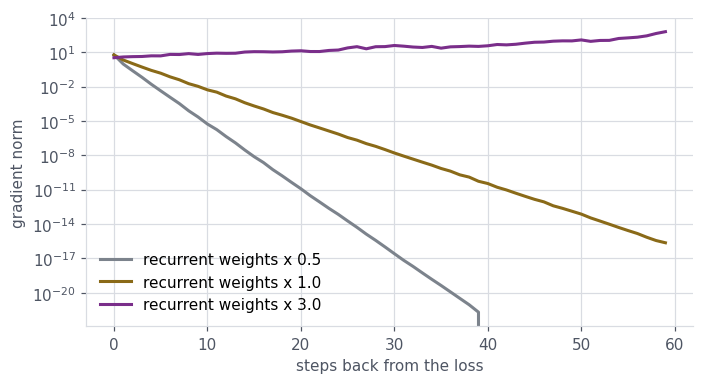

x 0.5:  last step 6.0e+00   first step 0.0e+00
x 1.0:  last step 5.8e+00   first step 2.3e-16
x 3.0:  last step 3.3e+00   first step 6.2e+02


In [5]:
def scaled_rnn(factor):
    def make():
        m = nn.RNN(8, 32, batch_first=True)
        with torch.no_grad():
            m.weight_hh_l0.mul_(factor)
        return m
    return make

curves = {f: grad_by_distance(scaled_rnn(f)) for f in (0.5, 1.0, 3.0)}

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for factor, color in zip(curves, (MUTED, AMBER, KEY)):
    ax.plot(curves[factor], color=color, lw=2, label=f"recurrent weights x {factor}")
ax.set_yscale("log")
ax.set_xlabel("steps back from the loss")
ax.set_ylabel("gradient norm")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

for factor, g in curves.items():
    print(f"x {factor}:  last step {g[0]:.1e}   first step {g[59]:.1e}")

With the recurrent weights multiplied by 3, the gradient **grows** with
distance instead of shrinking. The loss becomes huge or turns into `NaN`. With
the weights halved, it vanishes even faster: at the first step the gradient
underflows to exactly zero in 32-bit floats.

## 4. Gradient clipping fixes explosion, not vanishing

Clipping computes the global norm of all gradients and, if it exceeds a
threshold, rescales the whole gradient to that threshold. The direction is
preserved; only its length is capped.

In [6]:
torch.manual_seed(0)
model = scaled_rnn(3.0)()
x = torch.randn(4, 60, 8)
out, _ = model(x)
out[:, -1].pow(2).sum().backward()

norm_before = nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # returns the norm BEFORE clipping
norm_after = torch.sqrt(sum(p.grad.pow(2).sum() for p in model.parameters()))
print(f"Total gradient norm before clipping: {norm_before:.1f}")
print(f"Total gradient norm after clipping:  {norm_after:.4f}")

Total gradient norm before clipping: 21885.6
Total gradient norm after clipping:  1.0000


Now the other direction. Clipping multiplies the **whole** gradient by one
number, so it cannot change how the gradient is distributed across time steps.
We use the ordinary vanishing case (default weights).

In [7]:
torch.manual_seed(0)
model = plain_rnn()
x = torch.randn(4, 60, 8, requires_grad=True)
out, _ = model(x)
out[:, -1].pow(2).sum().backward()
per_step = x.grad.norm(dim=(0, 2)).flip(0)       # gradient norm at each step, 0 = last step

total = float(nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0))
scale = min(1.0, 1.0 / total)                    # the single factor clipping applies to every gradient
print(f"Total parameter-gradient norm: {total:.2f}, so clipping scales everything by {scale:.3f}")
print(f"first-step / last-step gradient ratio before clipping: {per_step[59] / per_step[0]:.1e}")
print(f"first-step / last-step gradient ratio after clipping:  {(per_step[59] * scale) / (per_step[0] * scale):.1e}")

Total parameter-gradient norm: 28.29, so clipping scales everything by 0.035
first-step / last-step gradient ratio before clipping: 6.9e-17
first-step / last-step gradient ratio after clipping:  6.9e-17


The ratio is identical before and after. Clipping tames a gradient that is too
large, but it cannot restore a signal that has already vanished. Vanishing needs
an architectural answer, which is Part 3.

## 5. Truncated BPTT and `detach()`

For very long sequences we cut the sequence into chunks, carry the hidden state
from one chunk to the next, but do **not** carry the gradient. Without
`detach()`, the second chunk's backward pass tries to reach back into the first
chunk's graph, which has already been freed.

In [8]:
def train_two_chunks(detach):
    rnn = nn.RNN(8, 32, batch_first=True)
    head = nn.Linear(32, 1)
    opt = torch.optim.SGD(list(rnn.parameters()) + list(head.parameters()), lr=0.01)
    h = torch.zeros(1, 4, 32)
    for chunk in range(3):
        if detach:
            h = h.detach()                      # keep the values, cut the graph
        out, h = rnn(torch.randn(4, 10, 8), h)
        loss = head(out).pow(2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return "completed all 3 chunks"

try:
    print("Without detach():", train_two_chunks(detach=False))
except RuntimeError as err:
    print("Without detach(): RuntimeError")
    print("   ", str(err)[:95])

print("With detach():   ", train_two_chunks(detach=True))

Without detach(): RuntimeError
    Trying to backward through the graph a second time (or directly access saved tensors after they
With detach():    completed all 3 chunks


## Try it

1. In section 3, add the factor 1.5 and 2. At roughly what scale does the
   gradient stop vanishing and start growing? Is the transition sharp?
2. Change `max_norm` in section 4 from 1.0 to 100. Is the exploding case still
   clipped? What does that say about choosing the threshold?
3. In section 2, change the sequence length from 60 to 30. Predict the gradient
   at the first step before you run it, then check.

## What this notebook showed

- BPTT is exactly ordinary backpropagation on the unrolled network: the two
  gradient routes agree to floating-point precision.
- For a plain tanh recurrent network, the gradient at the first of 60 steps is
  about 2e-16, against about 5.8 at the last step.
- Scaling the recurrent weights by 3 turns the same network from vanishing into
  exploding (about 3 at the last step, about 600 at the first). Clipping caps
  the exploding case at the threshold you choose and cannot change the
  vanishing case, because it rescales every gradient by the same factor.
- Truncated BPTT needs `h.detach()` between chunks, or PyTorch raises
  "Trying to backward through the graph a second time".